In [2]:
using CairoMakie, JLD2, Trapz, LinearAlgebra, StatsBase, Revise
includet("FigureStyles.jl")
using .FigureStyles
set_theme!(MyTheme)

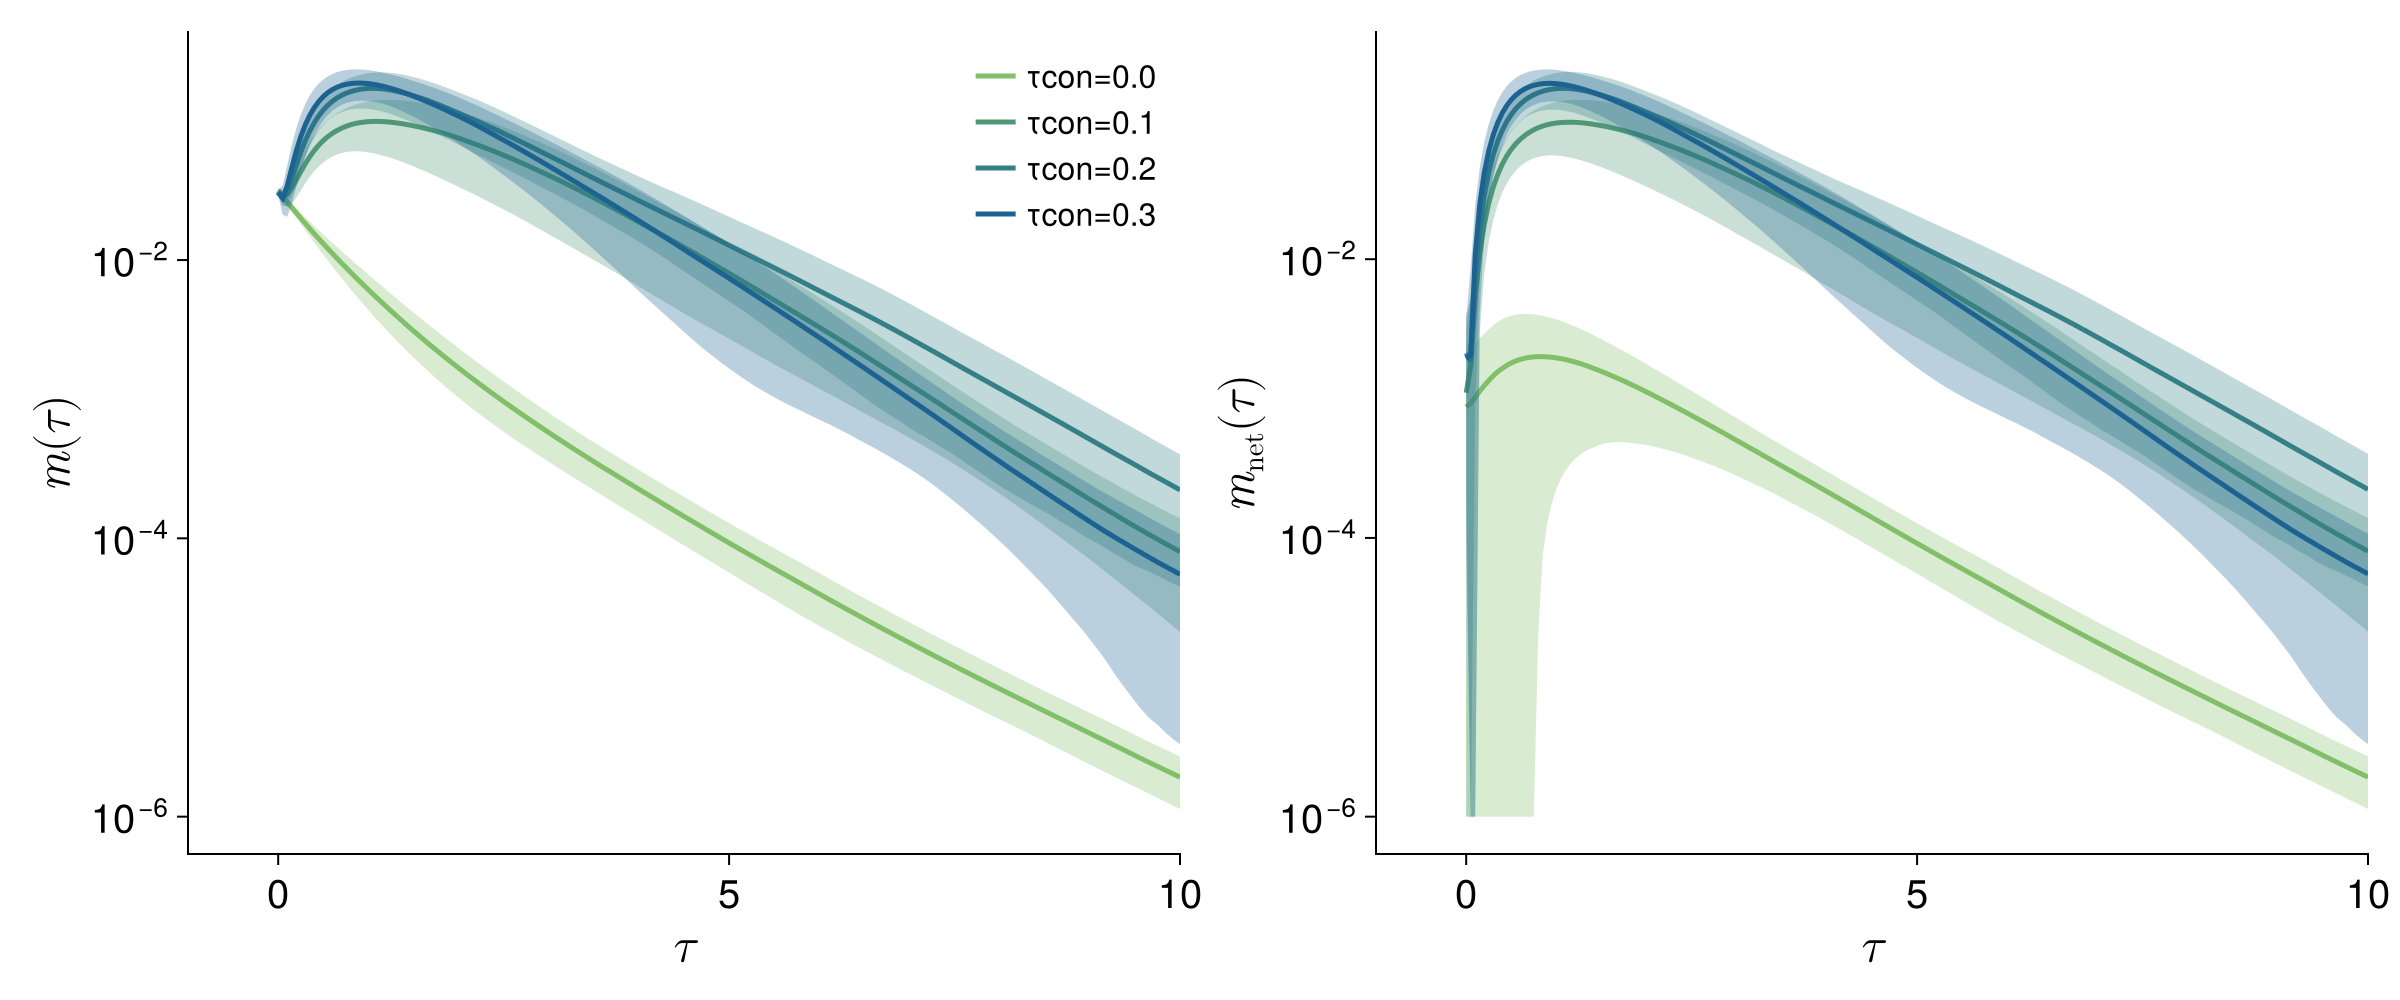

CairoMakie.Screen{IMAGE}


In [7]:
memory_files = filter(
    f -> startswith(f, "MemoryCurveConSearch") && endswith(f, ".jld2"),
    readdir("results"),
)
isempty(memory_files) && error("No MemoryCurveConSearch*.jld2 files found in $(data_dir).")
data_path = joinpath("results", last(sort(memory_files)))
data = load(data_path)

τ = data["τ"]
τcon_vec = data["τcon_vec"]
m_avg = data["m_avg"]
m_net_avg = data["m_net_avg"]
m_std = haskey(data, "m_std") ? data["m_std"] : dropdims(std(data["m_all"]; dims=2); dims=2)
m_net_std = haskey(data, "m_net_std") ? data["m_net_std"] : dropdims(std(data["m_net_all"]; dims=2); dims=2)
min_memory = 1e-6

colors = cgrad(:navia, 20, categorical=true)
colors = reverse(colors[[6,9,12,15]])
fig = Figure(size=(1200, 500))
ax_total = Axis(fig[1, 1]; xlabel=L"\tau", ylabel=L"m(\tau)", yscale=log10, limits=(-1.0, 10.0, nothing, nothing))
ax_net = Axis(fig[1, 2]; xlabel=L"\tau", ylabel=L"m_{\mathrm{net}}(\tau)", yscale=log10, limits=(-1.0, 10.0, nothing, nothing))

for (i, τcon) in enumerate(τcon_vec)
    label = "τcon=$(round(τcon; digits=2))"
    m_mean = max.(m_avg[:, i], min_memory)
    m_lower = max.(m_avg[:, i] .- m_std[:, i], min_memory)
    m_upper = max.(m_avg[:, i] .+ m_std[:, i], min_memory)
    mnet_mean = max.(m_net_avg[:, i], min_memory)
    mnet_lower = max.(m_net_avg[:, i] .- m_net_std[:, i], min_memory)
    mnet_upper = max.(m_net_avg[:, i] .+ m_net_std[:, i], min_memory)
    band!(ax_total, τ, m_lower, m_upper; color=(colors[i], 0.3))
    band!(ax_net, τ, mnet_lower, mnet_upper; color=(colors[i], 0.3))
    lines!(ax_total, τ, m_mean; color=colors[i], linewidth=2.5, label=label)
    lines!(ax_net, τ, mnet_mean; color=colors[i], linewidth=2.5, label=label)
end

axislegend(ax_total; framevisible=false, position=:rt)
display(fig)